<a href="https://colab.research.google.com/github/Khananiamna/stroke-prediction-ml-project/blob/main/.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv("healthcare-dataset-stroke-data.csv.csv")
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
# Basic information about the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
# Summary statistics for numeric columns
df.describe()


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [5]:
# Step 3: Data visualization

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


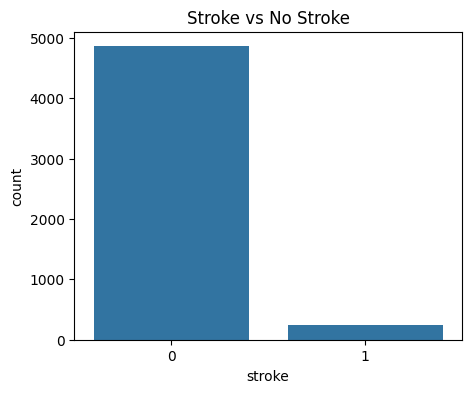

In [6]:
# 1. Count of stroke vs no stroke
plt.figure(figsize=(5,4))
sns.countplot(x="stroke", data=df)
plt.title("Stroke vs No Stroke")
plt.show()


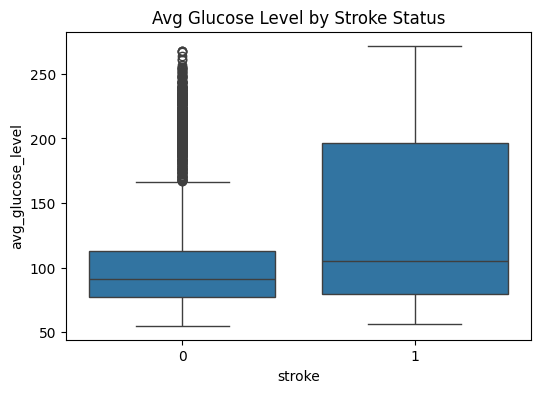

In [7]:
# 3. Average glucose level by stroke status
plt.figure(figsize=(6,4))
sns.boxplot(x="stroke", y="avg_glucose_level", data=df)
plt.title("Avg Glucose Level by Stroke Status")
plt.show()


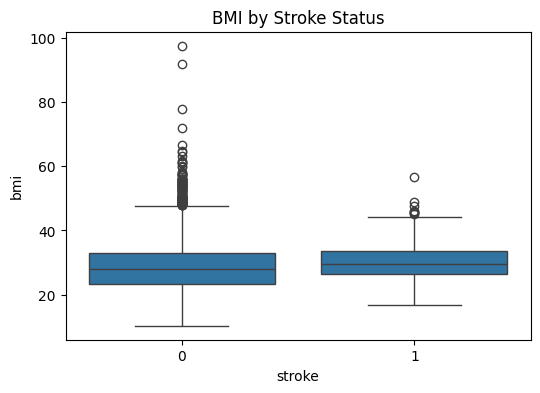

In [8]:
# 4. BMI by stroke status
plt.figure(figsize=(6,4))
sns.boxplot(x="stroke", y="bmi", data=df)
plt.title("BMI by Stroke Status")
plt.show()


In [9]:
# Step 4: Data preparation for supervised ML

# Drop ID column if present
if "id" in df.columns:
    df = df.drop(columns=["id"])

# Handle missing values: fill missing BMI with mean
if df["bmi"].isna().sum() > 0:
    df["bmi"] = df["bmi"].fillna(df["bmi"].mean())

# Separate features (X) and target (y)
X = df.drop(columns=["stroke"])
y = df["stroke"]

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [10]:
from sklearn.model_selection import train_test_split, StratifiedKFold

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# K-fold object (for later use if needed)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [11]:
# Step 5: Build and evaluate predictive models

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)


In [12]:
# Metrics for Decision Tree
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, zero_division=0)
dt_recall = recall_score(y_test, y_pred_dt, zero_division=0)

print("Decision Tree")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("\nClassification report:\n", classification_report(y_test, y_pred_dt, zero_division=0))



Decision Tree
Accuracy : 0.9060665362035225
Precision: 0.140625
Recall   : 0.18

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95       972
           1       0.14      0.18      0.16        50

    accuracy                           0.91      1022
   macro avg       0.55      0.56      0.55      1022
weighted avg       0.92      0.91      0.91      1022



In [13]:
# Metrics for Naive Bayes
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb, zero_division=0)
nb_recall = recall_score(y_test, y_pred_nb, zero_division=0)

print("Naive Bayes")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("\nClassification report:\n", classification_report(y_test, y_pred_nb, zero_division=0))


Naive Bayes
Accuracy : 0.18590998043052837
Precision: 0.05568181818181818
Recall   : 0.98

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.15      0.25       972
           1       0.06      0.98      0.11        50

    accuracy                           0.19      1022
   macro avg       0.52      0.56      0.18      1022
weighted avg       0.95      0.19      0.25      1022



In [14]:
# Step 6: Compare model performance

results = {
    "Model": ["Decision Tree", "Naive Bayes"],
    "Accuracy": [dt_accuracy, nb_accuracy],
    "Precision": [dt_precision, nb_precision],
    "Recall": [dt_recall, nb_recall]
}

comparison_df = pd.DataFrame(results)
comparison_df


,Model,Accuracy,Precision,Recall
0,Decision Tree,0.906067,0.140625,0.18
1,Naive Bayes,0.185910,0.055682,0.98
